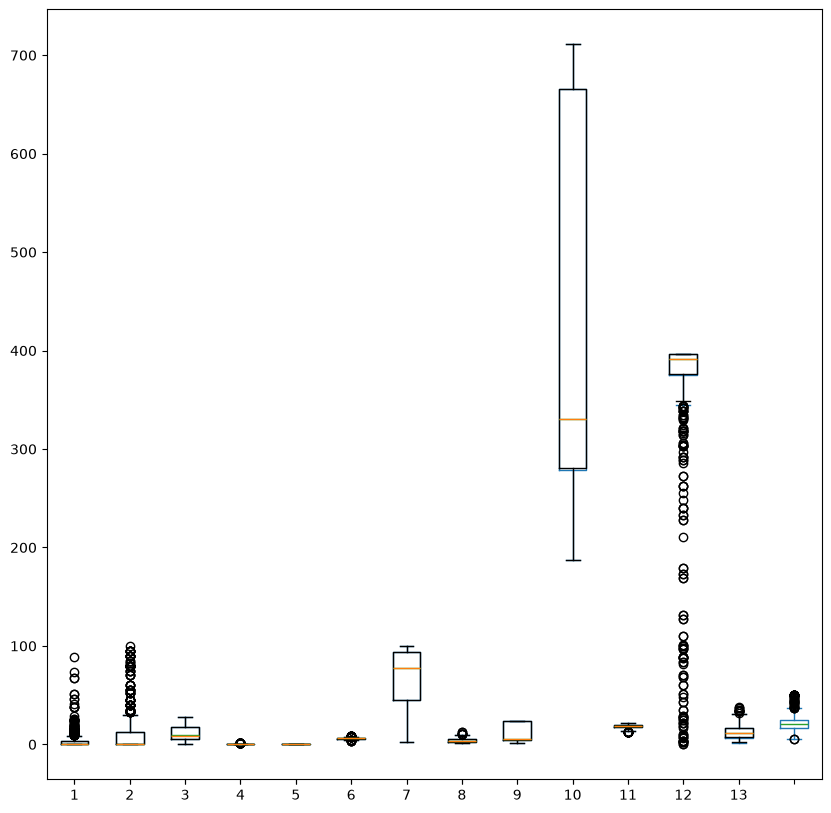

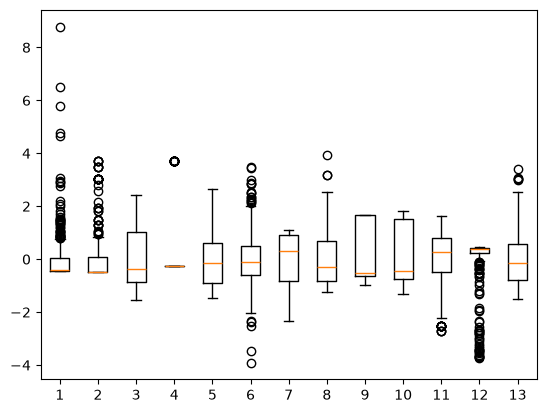

Epoch 1/5000
21/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 561.7161
Epoch 1: val_loss improved from None to 543.85626, saving model to ./model/housing_1001.keras

Epoch 1: finished saving model to ./model/housing_1001.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 558.2657 - val_loss: 543.8563
Epoch 2/5000
13/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 532.2252 
Epoch 2: val_loss improved from 543.85626 to 513.57275, saving model to ./model/housing_1001.keras

Epoch 2: finished saving model to ./model/housing_1001.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 530.9380 - val_loss: 513.5728
Epoch 3/5000
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 503.2238   
Epoch 3: val_loss improved from 513.57275 to 475.81131, saving model to ./model/housing_1001.keras

Epoch 3: finished saving model to ./model/housing_1001.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 499.3714 - val_loss: 475.8113
Epoch 4/5000
17/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 465.1707   
Epoc

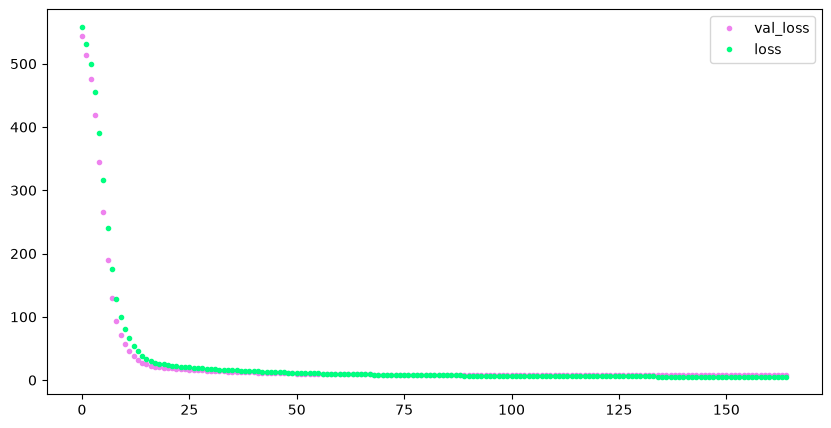

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step 
실제가격: 19.400, 예상가격: 19.261
실제가격: 10.900, 예상가격: 13.987
실제가격: 34.700, 예상가격: 30.279
실제가격: 15.600, 예상가격: 15.488
실제가격: 22.600, 예상가격: 24.559
실제가격: 29.000, 예상가격: 31.896
실제가격: 23.800, 예상가격: 21.441
실제가격: 45.400, 예상가격: 42.628
실제가격: 50.000, 예상가격: 45.894
실제가격: 26.700, 예상가격: 30.542


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# seed 값 설정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

df_pre = pd.read_csv("dataset/housing.csv", sep=r"\s+", header=None)
df = df_pre.sample(frac=1)
dataset = df.values

X = dataset[:, 0:13]
Y = dataset[:, 13]

df.plot.box(figsize=(10,10))

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=seed
)

plt.boxplot(X_train)
plt.show()

# 정규화 -> 모델의 학습이 안정적으로 이루어짐 -> 많은 경우 모델의 성능이 조금이라도 향상될 수 있음
mean = X_train.mean(axis=0)
X_train -= mean
std = X_train.std(axis=0)
X_train /= std
X_test -= mean
X_test /= std

plt.boxplot(X_train)
plt.show()

model = Sequential()
model.add(Input(shape=(13,)))             # 입력 특성 13개
model.add(Dense(30, activation='relu'))   # 첫 번째 은닉층
model.add(Dense(6, activation='relu'))
model.add(Dense(1))

model.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

# 자동 중단
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 자동 중단 설정
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=50
)

# 모델 저장 조건 설정
modelpath = "./model/housing_1001.keras"
checkpointer = ModelCheckpoint(
    filepath=modelpath,
    monitor='val_loss',
    verbose=1,
    save_best_only=True
)

history = model.fit(
    X_train,
    Y_train,
    validation_split=0.33,
    epochs=5000,
    batch_size=10,
    callbacks=[early_stopping_callback, checkpointer]
)

hist = pd.DataFrame(history.history)
print(hist.tail())

# 검증 데이터의 손실 저장
y_vloss = history.history['val_loss']

# 학습 데이터의 손실 저장
y_loss = history.history['loss']

import matplotlib.pyplot as plt

# 에포크별 학습 손실과 검증 손실 표시
x_len = np.arange(len(y_loss))
plt.figure(figsize=(10, 5))
plt.plot(
    x_len, y_vloss, "o",
    c="violet", markersize=3, label='val_loss'
)
plt.plot(
    x_len, y_loss, "o",
    c="springgreen", markersize=3, label='loss'
)

plt.legend()
plt.show()

# 예측 값과 실제 값의 비교
Y_prediction = model.predict(X_test).flatten()

for i in range(10):
    label = Y_test[i]
    prediction = Y_prediction[i]
    print("실제가격: {:.3f}, 예상가격: {:.3f}".format(label, prediction))